In [1]:
# imports
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_classif

# plotting Libraries
import seaborn as sns
import matplotlib.pyplot as plt

# preprocessing, model selection
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

# classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier

# metrics
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, roc_curve, auc
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

In [2]:
# random_state
SEED = 42

# Load train data
df_train = pd.read_csv('../data/train.csv')
df_train.head(5)

,id,Time,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,...,feat21,feat22,feat23,feat24,feat25,feat26,feat27,feat28,Transaction_Amount,IsFraud
0,0,0.0,2.074329,-0.129425,-1.137418,0.412846,-0.192638,-1.210144,0.110697,-0.263477,...,-0.334701,-0.887840,0.336701,-0.110835,-0.291459,0.207733,-0.076576,-0.059577,1.98,0
1,1,0.0,1.998827,-1.250891,-0.520969,-0.894539,-1.122528,-0.270866,-1.029289,0.050198,...,0.054848,-0.038367,0.133518,-0.461928,-0.465491,-0.464655,-0.009413,-0.038238,84.00,0
2,2,0.0,0.091535,1.004517,-0.223445,-0.435249,0.667548,-0.988351,0.948146,-0.084789,...,-0.326725,-0.803736,0.154495,0.951233,-0.506919,0.085046,0.224458,0.087356,2.69,0
3,3,0.0,1.979649,-0.184949,-1.064206,0.120125,-0.215238,-0.648829,-0.087826,-0.035367,...,-0.095514,-0.079792,0.167701,-0.042939,0.000799,-0.096148,-0.057780,-0.073839,1.00,0
4,4,0.0,1.025898,-0.171827,1.203717,1.243900,-0.636572,1.099074,-0.938651,0.569239,...,0.099157,0.608908,0.027901,-0.262813,0.257834,-0.252829,0.108338,0.021051,1.00,0


Perhaps, we can drop Time feature since it have near zero MI score.

# Data Preprocessing 

### Feature Scaling

We saw in 01_eda.ipynb that all features are scaled except for the 'Time' and the 'Transaction_Amount'.
To keep same magnitute for modeling we will perform scalers for both features.
We will use RobustScaler for the 'Transaction_Amount' column as it have outliers and StandardScaler for the 'Time' column.

In [3]:
# Scaling Time and amount values.
rob_scaler = RobustScaler() # is less prone to outliers
stnd_scaler = StandardScaler()

df_train['scaled_Transaction_Amount'] = rob_scaler.fit_transform(df_train['Transaction_Amount'].values.reshape(-1,1))
df_train['scaled_time'] = stnd_scaler.fit_transform(df_train['Time'].values.reshape(-1,1))

df_train.drop(['Time','Transaction_Amount'], axis=1, inplace = True)

# we have done it, but now we need to place columns at the first and second placee in our dataframe

scaled_amount = df_train['scaled_Transaction_Amount']
scaled_time = df_train['scaled_time']

df_train.drop(['scaled_Transaction_Amount', 'scaled_time'], axis=1, inplace=True)
df_train.insert(0, 'scaled_Transaction_Amount', scaled_amount)
df_train.insert(1, 'scaled_time', scaled_time)

All the features are scaled now.

In [4]:
df_train.head()

,scaled_Transaction_Amount,scaled_time,id,feat1,feat2,feat3,feat4,feat5,feat6,feat7,...,feat20,feat21,feat22,feat23,feat24,feat25,feat26,feat27,feat28,IsFraud
0,-0.342039,-2.657548,0,2.074329,-0.129425,-1.137418,0.412846,-0.192638,-1.210144,0.110697,...,-0.292969,-0.334701,-0.887840,0.336701,-0.110835,-0.291459,0.207733,-0.076576,-0.059577,0
1,0.881958,-2.657548,1,1.998827,-1.250891,-0.520969,-0.894539,-1.122528,-0.270866,-1.029289,...,0.065717,0.054848,-0.038367,0.133518,-0.461928,-0.465491,-0.464655,-0.009413,-0.038238,0
2,-0.331443,-2.657548,2,0.091535,1.004517,-0.223445,-0.435249,0.667548,-0.988351,0.948146,...,-0.021375,-0.326725,-0.803736,0.154495,0.951233,-0.506919,0.085046,0.224458,0.087356,0
3,-0.356663,-2.657548,3,1.979649,-0.184949,-1.064206,0.120125,-0.215238,-0.648829,-0.087826,...,-0.340089,-0.095514,-0.079792,0.167701,-0.042939,0.000799,-0.096148,-0.057780,-0.073839,0
4,-0.356663,-2.657548,4,1.025898,-0.171827,1.203717,1.243900,-0.636572,1.099074,-0.938651,...,-0.203628,0.099157,0.608908,0.027901,-0.262813,0.257834,-0.252829,0.108338,0.021051,0


### Builidng undersample

In [5]:
df_train = df_train.sample(frac=1, random_state=SEED) # shuffle dataframe
 # 1st takee all fraud cases
df_fraud = df_train.loc[df_train['IsFraud']==1]
#  2nd take random non fraud cases for the same rows number (they were shuffeled earlier)
df_nonfraud = df_train.loc[df_train['IsFraud']==0][:269] 
df_balanced_undersample = pd.concat([df_fraud, df_nonfraud]) # concatenate fraud and non fraud parts into one table
df_balanced_undersample = df_balanced_undersample.sample(frac=1, random_state=SEED) # shuffle them again

df_balanced_undersample.head()

,scaled_Transaction_Amount,scaled_time,id,feat1,feat2,feat3,feat4,feat5,feat6,feat7,...,feat20,feat21,feat22,feat23,feat24,feat25,feat26,feat27,feat28,IsFraud
105104,1.120728,0.648492,105104,1.113080,-1.169950,0.905338,-0.383838,-1.509870,-0.013515,-1.069088,...,-0.394424,-0.286429,-0.440277,-0.087724,0.002407,0.184426,0.569189,0.012917,0.022024,0
148715,-0.360394,1.272611,148715,-2.161337,1.333889,1.995527,0.854291,-0.332323,0.076561,0.159969,...,0.521020,-0.202639,0.221634,0.171239,0.084834,-0.362708,-0.268099,0.116900,0.055786,1
50691,-0.267124,-0.168757,50691,1.047601,-0.184769,1.295100,1.372780,-0.720048,0.858602,-0.721714,...,-0.213957,-0.294567,-0.483525,0.067034,0.014559,0.365037,-0.414823,0.087078,0.015902,0
119403,-0.356663,0.861158,119403,0.486726,1.965166,-3.169876,0.638165,1.764773,-0.850037,-0.286859,...,0.101818,-0.157737,-0.446565,0.038000,-1.695881,-0.231747,-0.283335,0.091699,0.096668,1
54329,-0.187882,-0.102993,54329,-2.098916,0.885524,1.578909,3.251237,-0.554025,-0.015814,0.017824,...,-0.097975,-0.055533,-0.079042,-0.111405,0.392864,-0.073775,0.403980,-1.297812,-0.262845,0


We have balanced undersample now

C:\Users\tinew\AppData\Local\Temp\ipykernel_29720\106595873.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='IsFraud', data=df_train, palette=colors)
C:\Users\tinew\AppData\Local\Temp\ipykernel_29720\106595873.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='IsFraud', data=df_balanced_undersample, palette=colors)


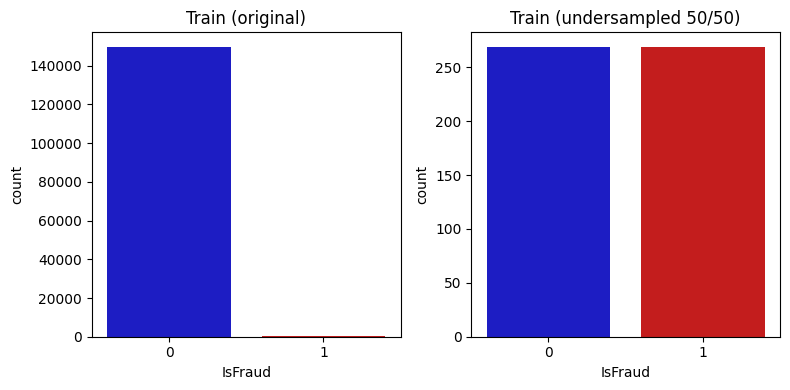

In [6]:
colors = ["#0101DF", "#DF0101"] # Fraud / non Fraud count plot colors

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
sns.countplot(x='IsFraud', data=df_train, palette=colors)
plt.title('Train (original)')

plt.subplot(1,2,2)
sns.countplot(x='IsFraud', data=df_balanced_undersample, palette=colors)
plt.title('Train (undersampled 50/50)')

plt.tight_layout()

Now lets take a look at a correlation matrixes for the undersample and the full dataframe

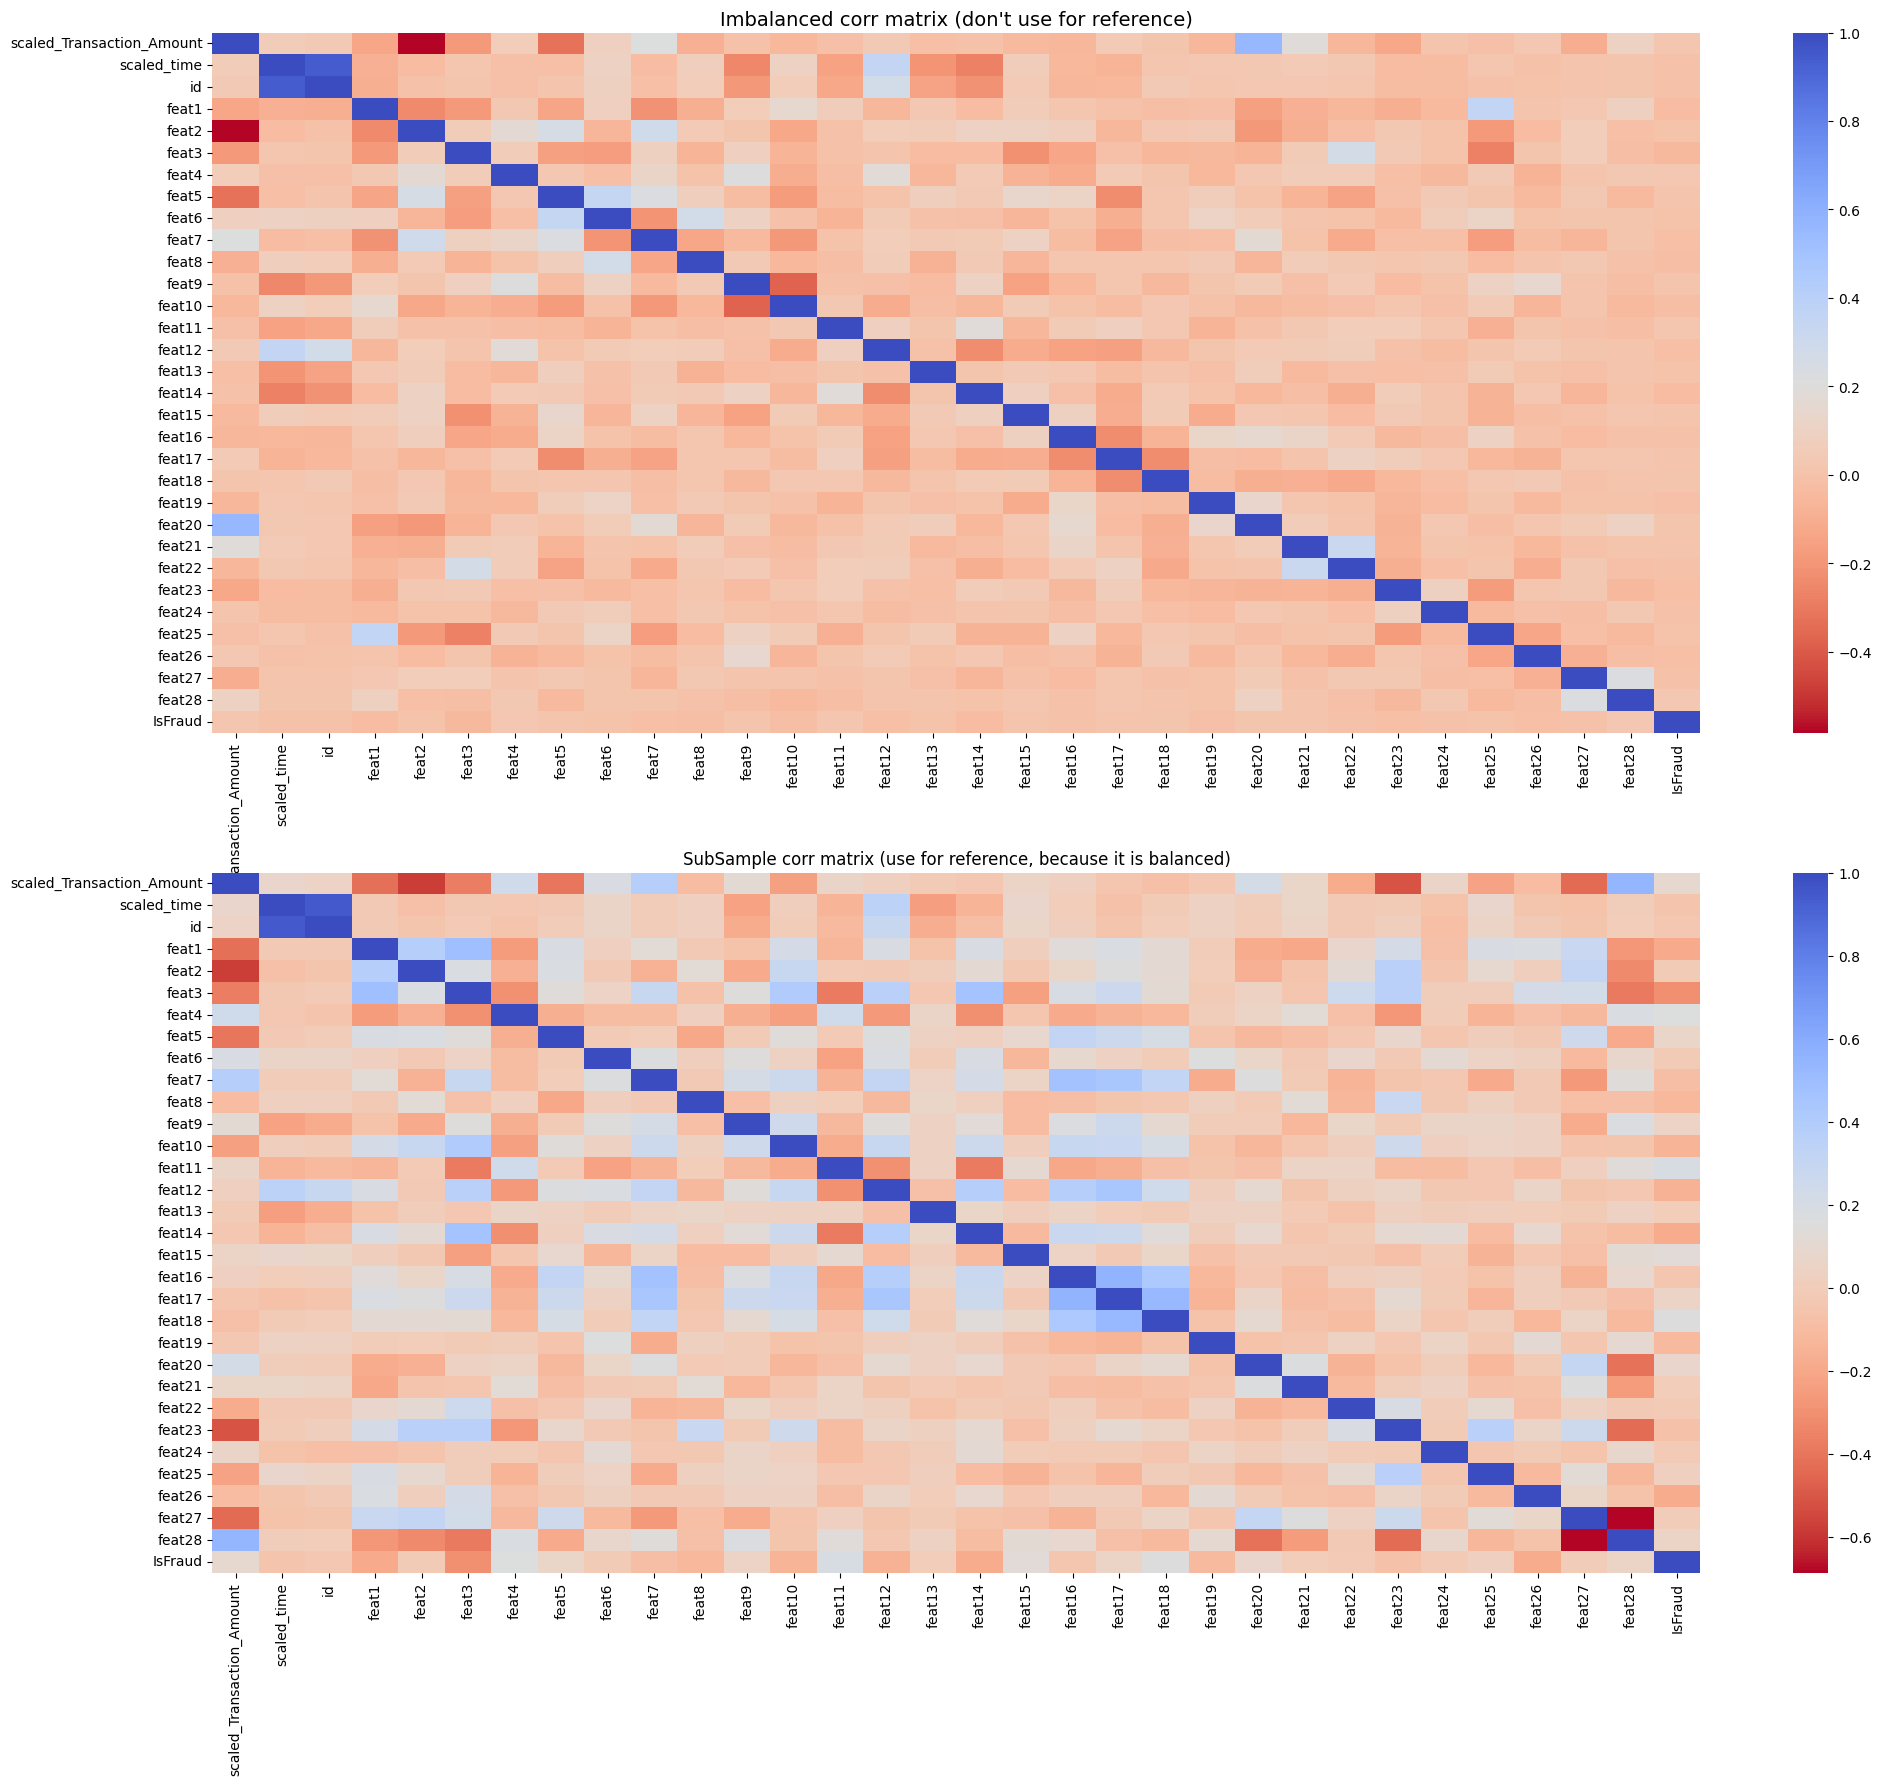

In [7]:
# now lets look at corr matrix for the new and old df (full)
f, (ax1, ax2) = plt.subplots(2,1,figsize=(24,20))

corr = df_train.corr()
sns.heatmap(corr, cmap='coolwarm_r', annot_kws={'size':20}, ax=ax1)
ax1.set_title("Imbalanced corr matrix (don't use for reference)", fontsize=14)

sub_sample_corr = df_balanced_undersample.corr()
sns.heatmap(sub_sample_corr, cmap='coolwarm_r', annot_kws={'size':20}, ax=ax2)
ax2.set_title("SubSample corr matrix (use for reference, because it is balanced)")
plt.show()

We see only few features which negatively correlates with isFraud column: feat1, feat3, feat26


C:\Users\tinew\AppData\Local\Temp\ipykernel_29720\3131961205.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IsFraud', y='feat1', data=df_balanced_undersample, palette=colors, ax=axes[0])
C:\Users\tinew\AppData\Local\Temp\ipykernel_29720\3131961205.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IsFraud', y='feat3', data=df_balanced_undersample, palette=colors, ax=axes[1])
C:\Users\tinew\AppData\Local\Temp\ipykernel_29720\3131961205.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IsFraud', y='feat26', data=df_balanced_u

Text(0.5, 1.0, 'feat19 vs class negative corr')

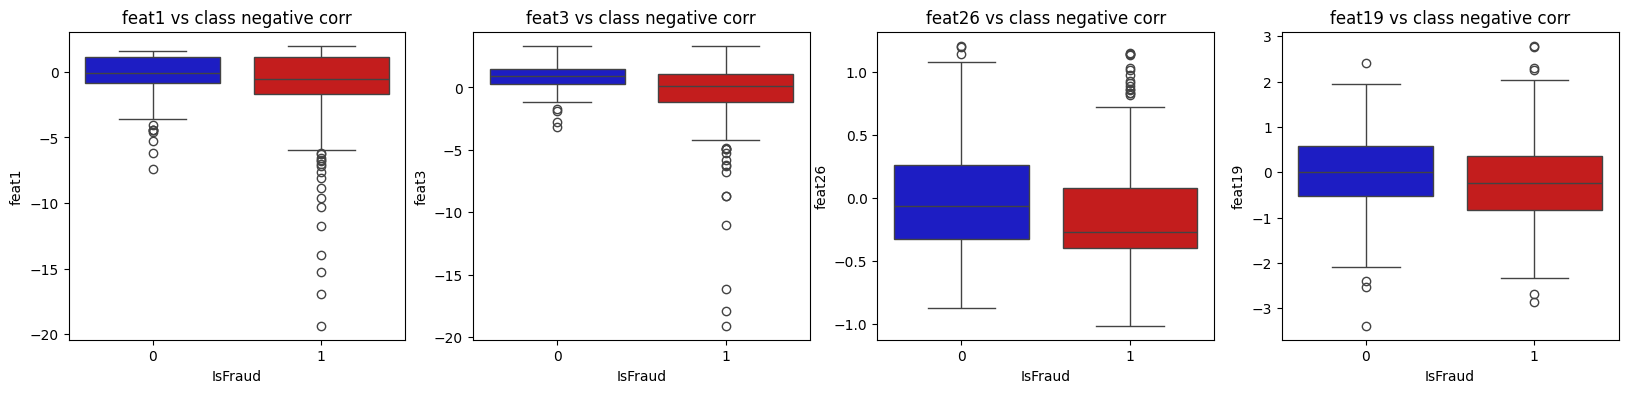

In [8]:
# boxplots for most interested features from the corr matrix
f, axes = plt.subplots(ncols=4, figsize=(20,4))

sns.boxplot(x='IsFraud', y='feat1', data=df_balanced_undersample, palette=colors, ax=axes[0])
axes[0].set_title('feat1 vs class negative corr')

sns.boxplot(x='IsFraud', y='feat3', data=df_balanced_undersample, palette=colors, ax=axes[1])
axes[1].set_title('feat3 vs class negative corr')

sns.boxplot(x='IsFraud', y='feat26', data=df_balanced_undersample, palette=colors, ax=axes[2])
axes[2].set_title('feat26 vs class negative corr')

sns.boxplot(x='IsFraud', y='feat19', data=df_balanced_undersample, palette=colors, ax=axes[3])
axes[3].set_title('feat19 vs class negative corr')




We see only few features which positive correlates with isFraud column: feat4 , feat11, feat18, feat15


C:\Users\tinew\AppData\Local\Temp\ipykernel_29720\349368425.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IsFraud', y='feat4', data=df_balanced_undersample, palette=colors, ax=axes[0])
C:\Users\tinew\AppData\Local\Temp\ipykernel_29720\349368425.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IsFraud', y='feat11', data=df_balanced_undersample, palette=colors, ax=axes[1])
C:\Users\tinew\AppData\Local\Temp\ipykernel_29720\349368425.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IsFraud', y='feat18', data=df_balanced_und

Text(0.5, 1.0, 'feat15 vs class positive corr')

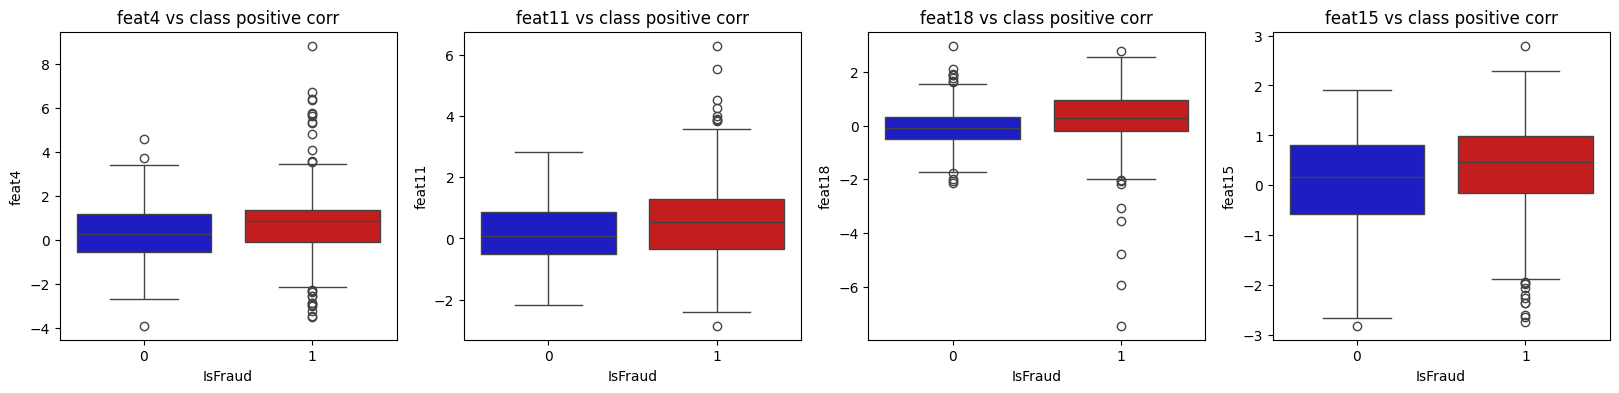

In [9]:
# boxplots for most interested features from the corr matrix
f, axes = plt.subplots(ncols=4, figsize=(20,4))

sns.boxplot(x='IsFraud', y='feat4', data=df_balanced_undersample, palette=colors, ax=axes[0])
axes[0].set_title('feat4 vs class positive corr')

sns.boxplot(x='IsFraud', y='feat11', data=df_balanced_undersample, palette=colors, ax=axes[1])
axes[1].set_title('feat11 vs class positive corr')

sns.boxplot(x='IsFraud', y='feat18', data=df_balanced_undersample, palette=colors, ax=axes[2])
axes[2].set_title('feat18 vs class positive corr')

sns.boxplot(x='IsFraud', y='feat15', data=df_balanced_undersample, palette=colors, ax=axes[3])
axes[3].set_title('feat15 vs class positive corr')

We see a small differences in the correllated features, nothing outstanding. So, just continue modeling with all the features.

In [10]:
# Split X and y
# df_balanced_undersample = df_balanced_undersample.copy()
y_balanced_undersample = df_balanced_undersample['IsFraud']
# X_balanced_undersample = df_balanced_undersample.drop(columns=['id'])
X_balanced_undersample = df_balanced_undersample.drop(columns=['IsFraud','id'])

Lets take a look at a feature importance from Mutual Information perspective.

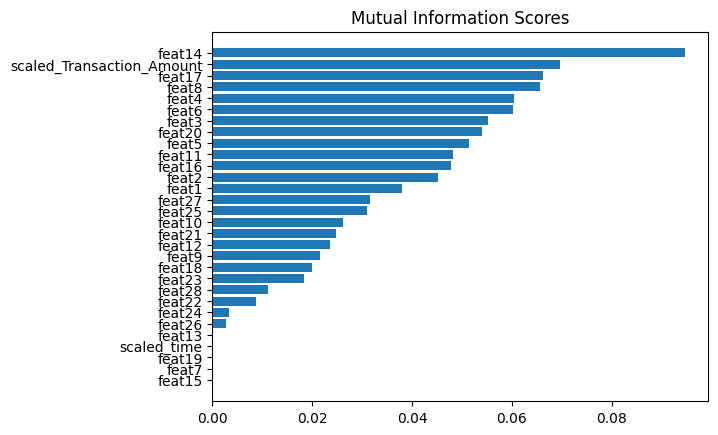

In [11]:
def make_mi_scores(X,y):
    X = X.copy()
    for colname in X.select_dtypes(['object', 'category']):
        x[colname], _ = X[colname].factorize()
    # All discrete features should now have integer dtypes
    discrete_features = [pd.api.types.is_integer_dtype(t) for t in X.dtypes]
    mi_scores = mutual_info_classif(X,y, discrete_features = discrete_features, random_state=0)
    mi_scores = pd.Series(mi_scores, name='MI Scores', index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

def plot_mi_scores(scores):
    '''Input: pandas series from def make_mi_scores'''
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title('Mutual Information Scores')

mi_scores = make_mi_scores(X_balanced_undersample,y_balanced_undersample)
plot_mi_scores(mi_scores)

That could help us to drop features with low MI score if we will need it in future. But now we just use all of them.

# Model comparison

Here we will test and choose the best classifier for balanced undersample

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X_balanced_undersample, y_balanced_undersample, test_size = 0.2, random_state=SEED)

In [13]:
# Values into arrays for feeding the classification algorithms
X_train = X_train.values
X_test = X_test.values
y_train = y_train.values
y_test = y_test.values

In [ ]:
# Implement simple classifiers
classifiers = {
    "LogisticRegression" : LogisticRegression(random_state=SEED),
    "KNearest" : KNeighborsClassifier(random_state=SEED),
    "Support Vector Classifier" : SVC(random_state=SEED),
    "DecisionTreeClassifier" : DecisionTreeClassifier(random_state=SEED),
    "Random Forest" : RandomForestClassifier(random_state=SEED),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators = 400, max_depth = 3, learning_rate = 0.01, random_state=SEED
    ),
    "Neural Network" : MLPClassifier(
                                hidden_layer_sizes=(50,50),
                                activation='relu',
                                solver='adam',
                                alpha=1e-3,
                                learning_rate_init=1e-3,
                                early_stopping=True,
                                validation_fraction=0.1,
                                max_iter=500,
                                random_state=SEED
                            )
}

for key, classifier in classifiers.items():
    # classifier.fit(X_train, y_train)
    training_score = cross_val_score(classifier, X_train, y_train, cv=5)
    print("Classifiers:", classifier.__class__.__name__, "Has a training score of", round(training_score.mean(), 2)*100, "% accuracy score")
print("-------------------------")
for key, classifier in classifiers.items():
    # classifier.fit(X_train, y_train)
    training_score = cross_val_score(classifier, X_train, y_train, cv=5, scoring='average_precision')
    print("Classifiers:", classifier.__class__.__name__, "Has a training score of", round(training_score.mean(), 2)*100, "average_precision")

Classifiers: LogisticRegression Has a training score of 69.0 % accuracy score
Classifiers: KNeighborsClassifier Has a training score of 68.0 % accuracy score
Classifiers: SVC Has a training score of 70.0 % accuracy score
Classifiers: DecisionTreeClassifier Has a training score of 65.0 % accuracy score
Classifiers: RandomForestClassifier Has a training score of 72.0 % accuracy score
Classifiers: GradientBoostingClassifier Has a training score of 71.0 % accuracy score
Classifiers: MLPClassifier Has a training score of 61.0 % accuracy score
-------------------------
Classifiers: LogisticRegression Has a training score of 76.0 average_precision
Classifiers: KNeighborsClassifier Has a training score of 70.0 average_precision
Classifiers: SVC Has a training score of 77.0 average_precision
Classifiers: DecisionTreeClassifier Has a training score of 59.0 average_precision
Classifiers: RandomForestClassifier Has a training score of 79.0 average_precision
Classifiers: GradientBoostingClassifier 

We choose the RandomForestClassifier since high level average_precision, accuracy, simplicity and performance. SVC also looks interesting.

In [ ]:
# fit model
model = RandomForestClassifier(n_estimators=400, random_state=SEED)
model.fit(X_train,y_train)

# predict test
preds = model.predict(X_test)

In [16]:
# Detaiiled precision/recall/F1 by class:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.57      0.73      0.64        45
           1       0.76      0.60      0.67        63

    accuracy                           0.66       108
   macro avg       0.66      0.67      0.66       108
weighted avg       0.68      0.66      0.66       108



In [17]:
# 2) ROC AUC for overall separability
probs = model.predict_proba(X_test)[:,1]
print('ROC AUC:', roc_auc_score(y_test, probs))

ROC AUC: 0.7082892416225749


In [18]:
# 3) Precision-Recall AUC (more informative when positives are rare):
precision, recall, _ = precision_recall_curve(y_test, probs)
print('PR AUC', auc(recall, precision))

PR AUC 0.8145003727070497


<function matplotlib.pyplot.show(close=None, block=None)>

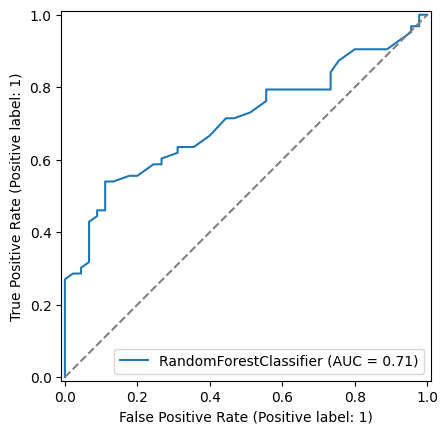

In [19]:
disp = RocCurveDisplay.from_estimator(
    model, X_test, y_test,
    # name=f'ROC (AUC = {roc_auc:.3f})'
)
plt.plot([0,1],[0,1],'--',color='gray')
plt.show

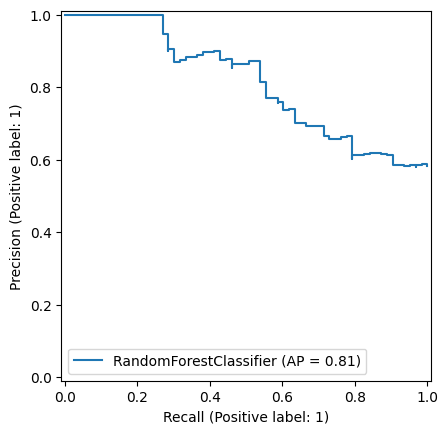

In [20]:
disp2 = PrecisionRecallDisplay.from_estimator(
    model, X_test, y_test,
)
plt.show()

# Submission

In [21]:
submission_data = pd.read_csv('../data/test.csv')
submission_data # prepare pipeline instead for that

,id,Time,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,...,feat20,feat21,feat22,feat23,feat24,feat25,feat26,feat27,feat28,Transaction_Amount
0,150000,73899,-0.681234,-0.371212,0.385966,0.955703,2.064078,0.338827,-0.539452,-0.254046,...,0.183560,-0.253324,0.266668,-0.153829,0.455969,-0.503628,0.257588,-0.456685,-0.298919,30.42
1,150001,73899,-1.098947,-0.959377,0.324934,0.703908,1.090582,-1.595909,0.584548,0.260069,...,0.334764,0.130108,0.676928,-0.161070,-0.638011,-0.273424,0.711132,0.349967,0.141233,23.00
2,150002,73899,0.977029,-0.270984,0.471526,-1.232570,0.957537,-0.636602,-0.953060,-1.491744,...,0.355728,0.517912,1.175087,-0.325895,-0.362636,0.306037,0.004828,0.037389,0.058222,198.00
3,150003,73900,1.176658,-0.225816,-0.246600,0.015513,1.103831,1.229516,-1.527098,-0.459769,...,-0.152613,-0.104600,0.003800,-0.023180,-0.458338,0.481427,-0.381415,0.080165,0.027372,9.99
4,150004,73900,0.804828,-0.272967,0.959910,-1.117567,0.395748,0.589855,1.059880,-1.101203,...,-0.127818,-0.011849,0.078540,-0.241700,0.010130,0.302614,-0.259568,0.023127,0.056957,239.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69124,219124,120580,1.891079,-0.041423,0.858158,-1.272908,-3.783908,-1.388939,-0.280639,2.012789,...,-0.195703,-0.181369,-0.456538,-0.069571,0.756765,0.244479,-0.147566,-0.054725,-0.044588,198.65
69125,219125,120580,0.139724,-0.917395,-0.257933,0.948649,-2.913655,-2.184829,-0.457534,1.883716,...,-0.116538,0.491469,1.478823,-0.085398,-0.091409,-1.053488,0.467570,0.358918,0.294735,24.00
69126,219126,120580,2.058343,0.391801,-0.136498,-0.038993,-1.928553,0.330117,0.179926,0.270127,...,-0.384830,-0.306640,-0.965783,0.307799,-0.021434,-0.343989,0.181065,-0.098387,-0.044064,1.79
69127,219127,120580,2.079227,0.301966,1.536193,-2.162389,-1.785833,-2.804889,-0.058879,0.552845,...,-0.190984,0.109909,0.590401,0.286621,0.675660,-0.510736,-0.090044,0.056749,-0.017126,88.00


In [22]:
submission_data2 = submission_data.drop('id', axis=1)
submission_data2

,Time,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,feat9,...,feat20,feat21,feat22,feat23,feat24,feat25,feat26,feat27,feat28,Transaction_Amount
0,73899,-0.681234,-0.371212,0.385966,0.955703,2.064078,0.338827,-0.539452,-0.254046,0.010960,...,0.183560,-0.253324,0.266668,-0.153829,0.455969,-0.503628,0.257588,-0.456685,-0.298919,30.42
1,73899,-1.098947,-0.959377,0.324934,0.703908,1.090582,-1.595909,0.584548,0.260069,0.057549,...,0.334764,0.130108,0.676928,-0.161070,-0.638011,-0.273424,0.711132,0.349967,0.141233,23.00
2,73899,0.977029,-0.270984,0.471526,-1.232570,0.957537,-0.636602,-0.953060,-1.491744,0.226865,...,0.355728,0.517912,1.175087,-0.325895,-0.362636,0.306037,0.004828,0.037389,0.058222,198.00
3,73900,1.176658,-0.225816,-0.246600,0.015513,1.103831,1.229516,-1.527098,-0.459769,0.749163,...,-0.152613,-0.104600,0.003800,-0.023180,-0.458338,0.481427,-0.381415,0.080165,0.027372,9.99
4,73900,0.804828,-0.272967,0.959910,-1.117567,0.395748,0.589855,1.059880,-1.101203,0.066464,...,-0.127818,-0.011849,0.078540,-0.241700,0.010130,0.302614,-0.259568,0.023127,0.056957,239.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69124,120580,1.891079,-0.041423,0.858158,-1.272908,-3.783908,-1.388939,-0.280639,2.012789,2.666080,...,-0.195703,-0.181369,-0.456538,-0.069571,0.756765,0.244479,-0.147566,-0.054725,-0.044588,198.65
69125,120580,0.139724,-0.917395,-0.257933,0.948649,-2.913655,-2.184829,-0.457534,1.883716,-1.056824,...,-0.116538,0.491469,1.478823,-0.085398,-0.091409,-1.053488,0.467570,0.358918,0.294735,24.00
69126,120580,2.058343,0.391801,-0.136498,-0.038993,-1.928553,0.330117,0.179926,0.270127,-0.735664,...,-0.384830,-0.306640,-0.965783,0.307799,-0.021434,-0.343989,0.181065,-0.098387,-0.044064,1.79
69127,120580,2.079227,0.301966,1.536193,-2.162389,-1.785833,-2.804889,-0.058879,0.552845,4.038013,...,-0.190984,0.109909,0.590401,0.286621,0.675660,-0.510736,-0.090044,0.056749,-0.017126,88.00


In [23]:
# Scaling Time and amount values.
# rob_scaler = RobustScaler() # is less prone to outliers
# stnd_scaler = StandardScaler()

submission_data2['scaled_Transaction_Amount'] = rob_scaler.transform(submission_data2['Transaction_Amount'].values.reshape(-1,1))
submission_data2['scaled_time'] = stnd_scaler.transform(submission_data2['Time'].values.reshape(-1,1))

submission_data2.drop(['Time','Transaction_Amount'], axis=1, inplace = True)

# we have done it, but now we need to place columns at the first and second placee in our dataframe

scaled_amount = submission_data2['scaled_Transaction_Amount']
scaled_time = submission_data2['scaled_time']

submission_data2.drop(['scaled_Transaction_Amount', 'scaled_time'], axis=1, inplace=True)
submission_data2.insert(0, 'scaled_Transaction_Amount', scaled_amount)
submission_data2.insert(1, 'scaled_time', scaled_time)

In [24]:
preds_for_submission = model.predict_proba(submission_data2)

c:\Users\tinew\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [25]:
output = pd.DataFrame(
    {
        'id' : submission_data.id,
        'IsFraud' : preds_for_submission[:,1]
    }
)
output.to_csv('submission.csv', index=False)
output

,id,IsFraud
0,150000,0.30
1,150001,0.44
2,150002,0.57
3,150003,0.50
4,150004,0.55
...,...,...
69124,219124,0.55
69125,219125,0.64
69126,219126,0.74
69127,219127,0.53


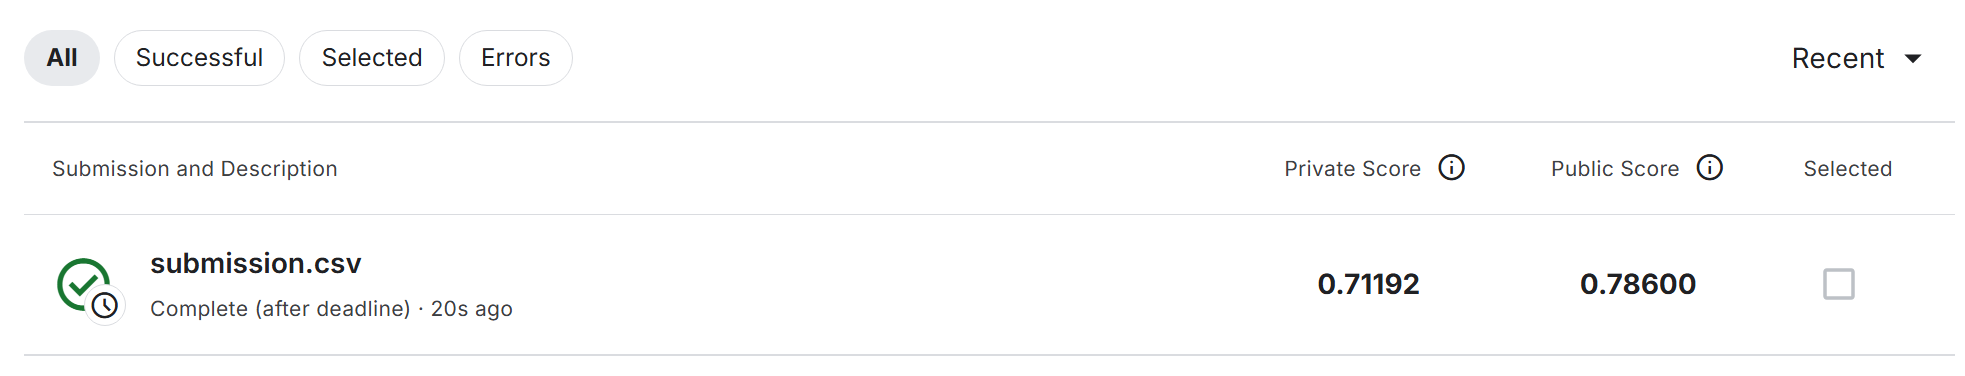

private score 71.1192 public score 0.78600